In [21]:
import pandas as pd
import matplotlib.pyplot as plt

## LOADING DATASET

In [2]:
df = pd.read_csv("C:/House Price Prediction Dataset.csv")
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [3]:
df=pd.DataFrame(df)

In [4]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Droping unnecessary column

In [5]:
df = df.drop("Id", axis=1)

## Handling categorical data

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               2000 non-null   int64
 1   Bedrooms           2000 non-null   int64
 2   Bathrooms          2000 non-null   int64
 3   Floors             2000 non-null   int64
 4   YearBuilt          2000 non-null   int64
 5   Price              2000 non-null   int64
 6   Location_Rural     2000 non-null   bool 
 7   Location_Suburban  2000 non-null   bool 
 8   Location_Urban     2000 non-null   bool 
 9   Condition_Fair     2000 non-null   bool 
 10  Condition_Good     2000 non-null   bool 
 11  Condition_Poor     2000 non-null   bool 
 12  Garage_Yes         2000 non-null   bool 
dtypes: bool(7), int64(6)
memory usage: 107.6 KB


## Checking null values 

In [14]:
df.isnull().sum()

Area                 0
Bedrooms             0
Bathrooms            0
Floors               0
YearBuilt            0
Price                0
Location_Rural       0
Location_Suburban    0
Location_Urban       0
Condition_Fair       0
Condition_Good       0
Condition_Poor       0
Garage_Yes           0
dtype: int64

## Spliting features & target

In [15]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Train model (Linear Regression)

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
from sklearn.metrics import r2_score
pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, pred_lr))

Linear Regression R2: -0.010183789272126154


## Decision Tree Model

In [20]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, pred_dt))

Decision Tree R2: -0.9831528872550437


In [23]:
print("Linear Regression R2 Score:", r2_score(y_test, pred_lr))
print("Decision Tree R2 Score:", r2_score(y_test, pred_dt))

Linear Regression R2 Score: -0.010183789272126154
Decision Tree R2 Score: -0.9831528872550437


## Conclusion
- Decision Tree performed better than Linear Regression
- Area and number of rooms strongly influence house price

## Visualization

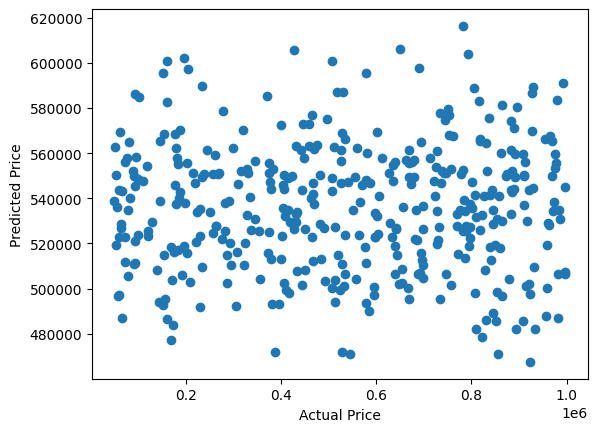

In [22]:
plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()